# Bitcoin Price API Wrapper Demo

This notebook demonstrates using the `rasa_utils.py` BitcoinAPI wrapper to:
1. Fetch live Bitcoin prices.  
2. Retrieve historical data.  
3. Compute trend statistics.  
4. Visualize time series and moving averages.

See the full API documentation in [rasa.API.md](./rasa.API.md).

## Imports

In [50]:
# Enable inline plotting and auto-reload of changed modules.
%matplotlib inline
%load_ext autoreload
%autoreload 2

# Import standard libraries.
import pandas as pd
import matplotlib.pyplot as plt

# Import the local BitcoinAPI wrapper.
from rasa_utils import BitcoinAPI

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Fetching the Current Price

In [51]:
import requests

# Instantiate the BitcoinAPI client.
api = BitcoinAPI(vs_currency="usd")

# Fetch the current price with error handling.
try:
    current_price = api.get_current_price()
    print(f"Current BTC price (USD): ${current_price:,.2f}")
except requests.HTTPError as e:
    # 429 or other HTTP errors
    status = e.response.status_code if e.response is not None else "N/A"
    print(f"Error fetching current price (HTTP {status}): {e}")
    print("You may have hit the API rate limit—try again in a minute.")


Current BTC price (USD): $103,275.00


## 2. Retrieving Historical Data
Fetch the last 14 days of daily closing prices.

In [52]:
# Retrieve 14 days of price history with error handling.
try:
    df = api.get_historical_data(days=14, interval="daily")
    display(df.head())
    df.info()
    df.describe()
except requests.HTTPError as e:
    status = e.response.status_code if e.response is not None else "N/A"
    print(f"Error fetching historical data (HTTP {status}): {e}")
    print("Skipping downstream analysis.")
    df = pd.DataFrame(columns=["timestamp","price"])  # empty fallback

,timestamp,price
0,2025-05-04,95922.868424
1,2025-05-05,94326.620485
2,2025-05-06,94758.823711
3,2025-05-07,96854.531988
4,2025-05-08,97026.493770


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  15 non-null     datetime64[ns]
 1   price      15 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 368.0 bytes


## 3. Summary Statistics

In [53]:
# Compute high, low, and mean over the period.
stats = api.summarize_trends(df)
print("14-day summary:")
for k, v in stats.items():
    print(f"  {k.title()}: ${v:,.2f}")

14-day summary:
  High: $104,630.88
  Low: $94,326.62
  Mean: $100,984.04


## 4. Plotting the Price Time Series

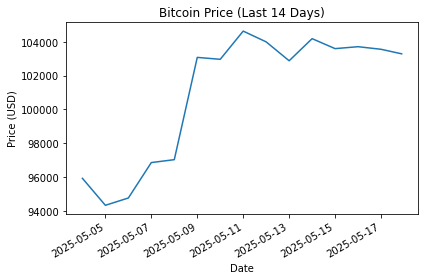

In [54]:
# Plot the closing price for the last 14 days.
ax = df.set_index("timestamp")["price"].plot(
    title="Bitcoin Price (Last 14 Days)"
)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
plt.tight_layout()

## 5. 7-Day Moving Average Overlay

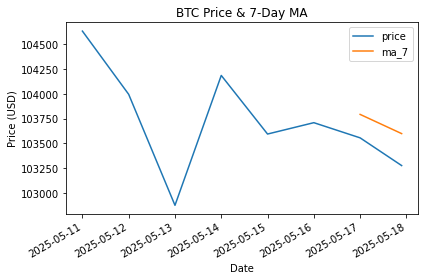

In [55]:
# Retrieve 7 days of data.
df7 = api.get_historical_data(days=7)

# Compute a 7-day rolling average.
df7["ma_7"] = df7["price"].rolling(window=7).mean()

# Plot price and moving average.
ax = df7.set_index("timestamp")[["price","ma_7"]].plot(
    title="BTC Price & 7-Day MA"
)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
plt.tight_layout()

## 6. Simulating the Rasa Custom Action

In [56]:
# Simulate the custom action that the chatbot would call.
def get_btc_price_utterance() -> str:
    api = BitcoinAPI("usd")
    return f"The current Bitcoin price is ${api.get_current_price():,.2f}"

# Display the simulated bot response.
print(get_btc_price_utterance())

The current Bitcoin price is $103,275.00


## Conclusion

- Wrapped CoinGecko endpoints in `BitcoinAPI`.  
- Fetched live & historical data.  
- Computed summary statistics.  
- Visualized the price series and moving average.  
- Simulated the Rasa custom action response.